# Quantum Computing Lab - Assignment 5
## Mrudula A Mahindrakar
### EE25S011

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import HamiltonianGate
from qiskit import transpile
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Operator


from qiskit_ibm_runtime.fake_provider import FakeAthensV2
from qiskit_aer.noise import NoiseModel

from scipy.linalg import expm
import warnings
from numpy.linalg import solve, eig

# Problem 1: HHL Algorithm 

To solve the linear system of equation: $A∣x⟩=∣b⟩$

A = $\begin{pmatrix} 1 & 0 & 0 & -1  \\\\ 0 & 1 & 0 & 0 \\\\ 0 & 0 & 1 & 0 \\\\ 1 & 0 & 0 & 1\end{pmatrix}$ 
b $ \in \{ \begin{pmatrix} 1 \\\\ 0 \\\\ 0 \\\\ 0 \end{pmatrix}, \begin{pmatrix} 0 \\\\ 1 \\\\ 0 \\\\ 0 \end{pmatrix}, \begin{pmatrix} 0 \\\\ 0 \\\\ 1 \\\\ 0 \end{pmatrix}, \begin{pmatrix} 0 \\\\ 0 \\\\ 0 \\\\ 1 \end{pmatrix} \}$

A is not hermitian, so we define 

C = $\begin{pmatrix} 0 & A \\\\ A^+ & 0 \end{pmatrix}$

So that $\begin{pmatrix} 0 & A \\\\ A^+ & 0 \end{pmatrix}$ . $\begin{pmatrix} 0 \\\\ x \end{pmatrix}$ = $\begin{pmatrix} b \\\\ 0 \end{pmatrix}$

In [2]:
# Define Matrix and Analyze Spectrum
A = np.array([[1, 0, 0, -1], 
                   [0, 1, 0, 0], 
                   [0, 0, 1, 0], 
                   [1, 0, 0, 1]], dtype=complex)

eigvals, eigvecs = eig(A)

print("Eigenvalues:")
print(eigvals)

basis_vectors = [
    np.array([1,0,0,0], dtype=complex),
    np.array([0,1,0,0], dtype=complex),
    np.array([0,0,1,0], dtype=complex),
    np.array([0,0,0,1], dtype=complex)
]

Eigenvalues:
[1.+1.j 1.-1.j 1.+0.j 1.+0.j]


In [3]:
def classical_solution(A, b):
    return solve(A, b)

for i, b in enumerate(basis_vectors):
    x = classical_solution(A, b)
    print(f"Solution for basis vector {i}:")
    print(x)

Solution for basis vector 0:
[ 0.5+0.j  0. +0.j  0. +0.j -0.5+0.j]
Solution for basis vector 1:
[0.+0.j 1.+0.j 0.+0.j 0.+0.j]
Solution for basis vector 2:
[0.+0.j 0.+0.j 1.+0.j 0.+0.j]
Solution for basis vector 3:
[0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]


In [4]:
A_dag = A.conj().T
zeros = np.zeros((4, 4))
C = np.block([[zeros, A], 
              [A_dag, zeros]])

eigvals = np.linalg.eigvals(C)
print(eigvals)
lambda_max = np.max(np.abs(eigvals))
t = 2 * np.pi * (2**i) / 4 

print("Matrix C is Hermitian:", np.allclose(C, C.conj().T))
print("Hermitian matrix C shape:", C.shape)

[ 1.41421356+0.j -1.41421356+0.j  1.        +0.j -1.        +0.j
  1.41421356+0.j  1.        +0.j -1.41421356+0.j -1.        +0.j]
Matrix C is Hermitian: True
Hermitian matrix C shape: (8, 8)


In [5]:
def controlled_U(circuit, clock, system, C, t):
    sys_qubits = list(system)
    for i in range(len(clock)):
        U = HamiltonianGate(C, t * (2**i),label ="U")
        CU = U.control()
        circuit.append(CU, [clock[i]] + sys_qubits)

In [6]:
def conditional_rotation(circuit, clock, ancilla):
    # controlled-Ry gates for 2*arcsin(1/lambda)
    for i in range(len(clock)):
        theta = 2 * np.pi / (2**(i+1))
        circuit.cry(theta, clock[i], ancilla)

In [7]:
def qft(circ, q, n):
    for j in range(n):
        circ.h(q[j])
        for k in range(j+1, n):
            circ.cp(np.pi / (2**(k-j)), q[k], q[j])

    # Reverse qubit order
    for j in range(n // 2):
        circ.swap(q[j], q[n - j - 1])

def qft_dagger(circ, q, n):
    for j in range(n // 2):
        circ.swap(q[j], q[n - j - 1])

    # Apply inverse rotations
    for j in reversed(range(n)):
        for k in reversed(range(j+1, n)):
            circ.cp(-np.pi / (2**(k-j)), q[k], q[j])
        circ.h(q[j])

In [8]:
def qpe(circuit, clock, system, C, t):
    
    circuit.h(clock)
    controlled_U(circuit, clock, system, C, t)
    #qft_dagger(circuit, clock, len(clock))
    circuit.append(QFT(len(clock)).inverse(), clock)
    
def inv_qpe(circuit, clock, system, C, t):
    
    #qft(circuit, clock, len(clock))
    circuit.append(QFT(len(clock)), clock)
    controlled_U(circuit, clock, system, C, -t)
    circuit.h(clock)

In [9]:
# def build_hhl_circuit(C, b, num_phase_qubits=3):
    
#     n_system = 3          # 8-dimensional space
#     n_clock = 3           # precision qubits
#     t = np.pi / 4

#     # 3 qubits for system (8x8 matrix), 2 for clock, 1 
    
#     qr_a = QuantumRegister(1, 'ancilla')
#     qr_c = QuantumRegister(n_clock, 'clock')
#     qr_s = QuantumRegister(n_system, 'system')
#     cr = ClassicalRegister(4, 'meas')
    
#     qc = QuantumCircuit(qr_a, qr_c, qr_s, cr)
    
#     b_padded = np.concatenate([b, np.zeros(4)])
#     b_padded = b_padded / np.linalg.norm(b_padded)
#     qc.initialize(b_padded, qr_s)
    
#     qpe(qc, qr_c, qr_s, C, t)
    
#     conditional_rotation(qc, qr_c, qr_a)
    
#     inv_qpe(qc, qr_c, qr_s, C, t)

#     qc.save_statevector()

#     qc.measure(qr_a, cr[0]) 
#     qc.measure(qr_s, cr[1:])
        
#     return qc

In [10]:
def build_hhl_circuit(C, b, num_phase_qubits,n_system,n_clock ):
    t = np.pi / 4
    
    # 3 qubits for system (8x8 matrix), 2 for clock, 1 
    
    qr_a = QuantumRegister(1, 'ancilla')
    qr_c = QuantumRegister(n_clock, 'clock')
    qr_s = QuantumRegister(n_system, 'system')
    cr = ClassicalRegister(n_system + 1, 'meas')
    
    qc = QuantumCircuit(qr_a, qr_c, qr_s, cr)
    
    b_padded = np.concatenate([b, np.zeros(len(C) - len(b))])
    b_padded = b_padded / np.linalg.norm(b_padded)
    qc.initialize(b_padded, qr_s)
    
    qpe(qc, qr_c, qr_s, C, t)
    
    conditional_rotation(qc, qr_c, qr_a)
    
    inv_qpe(qc, qr_c, qr_s, C, t)
    
    qc.save_statevector()
    
    qc.measure(qr_a, cr[0]) 
    qc.measure(qr_s, cr[1:])
    
    qc.draw("mpl")

    return qc

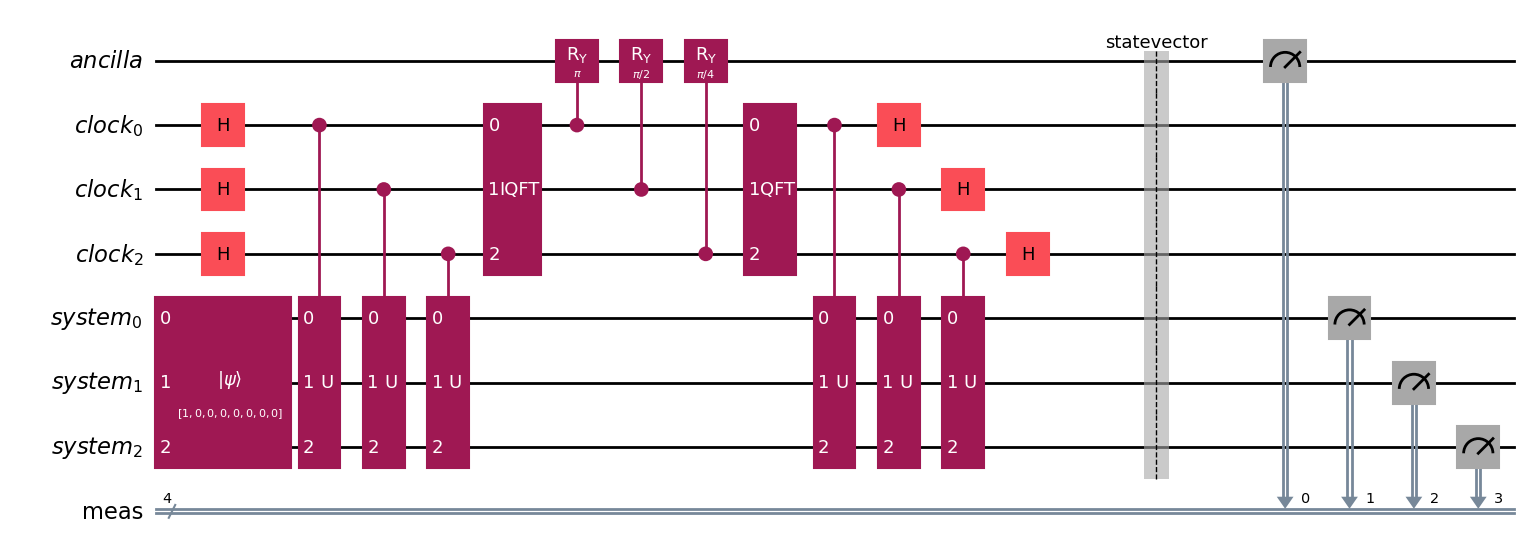

In [11]:
warnings.filterwarnings("ignore", category=DeprecationWarning)

n_system = 3          # 8-dimensional space
n_clock = 3           # precision qubits
num_phase_qubits = 3

qc = build_hhl_circuit(C, basis_vectors[0],num_phase_qubits,n_system,n_clock)
qc.draw("mpl")

{'0000': 833, '1000': 3937, '1001': 375, '0001': 10710, '1110': 3807, '1111': 338}


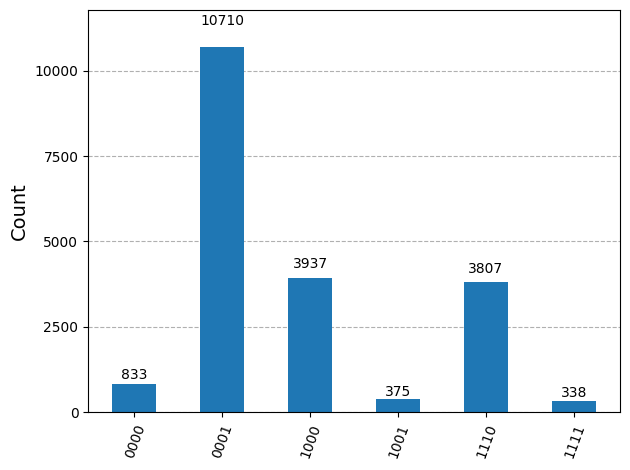

In [12]:
sim = AerSimulator()
compiled_circuit = transpile(qc, sim)
job_circuit = sim.run(compiled_circuit, shots=20000)

result_circuit = job_circuit.result()
counts_circuit = result_circuit.get_counts()

print(counts_circuit)

plot_histogram(counts_circuit)

In [13]:
state_data = result.data(tqc)['statevector']

# Index formula: (system_value * 2^4) + (0 * 2^1) + 1
solution_indices = [i * 16 + 1 for i in range(8)]

raw_solution = [state_data[idx] for idx in solution_indices]

x_quantum = np.array(raw_solution[:4])

x_quantum_real = np.real(x_quantum)
x_quantum_real[np.abs(x_quantum_real) < 1e-10] = 0

print("Final Quantum Solution (Unnormalized):")
print(x_quantum_real)

# Normalize to compare with classical solution 
norm = np.linalg.norm(x_quantum_real)
if norm > 0:
    print("\nNormalized Solution:")
    print(x_quantum_real / norm)

NameError: name 'result' is not defined

In [ ]:
def run_experiment(sim_type, simulator):
    print(f"\n--- Running on {sim_type} Simulator ---")
    for i, b in enumerate(basis_vectors):
        # Build the scratch circuit
        qc = build_hhl_circuit(C, b,num_phase_qubits,n_system,n_clock)
        
        # Transpile and Run
        t_qc = transpile(qc, simulator)
        result = simulator.run(t_qc, shots=8192).result()
        counts = result.get_counts()
        
        print(f"Basis Vector b_{i} result (Counts): {counts}")

    return result

In [ ]:
ideal_sim = AerSimulator()

warnings.filterwarnings("ignore", category=DeprecationWarning)

Ideal_result = run_experiment("Ideal", ideal_sim)

counts_circuit_ideal = Ideal_result.get_counts()

display(plot_histogram(counts_circuit_ideal))


In [ ]:
fake_backend = FakeAthensV2()
noise_model = NoiseModel.from_backend(fake_backend)
noisy_sim = AerSimulator(noise_model=noise_model)

warnings.filterwarnings("ignore", category=DeprecationWarning)

Noisy_result = run_experiment("Noisy", noisy_sim)
counts_circuit_noisy = Noisy_result.get_counts()

display(plot_histogram(counts_circuit_noisy))

# Part b

In [ ]:
import numpy as np
from scipy.linalg import solve

A_9 = np.eye(9, dtype=complex)
A_9[0, 0] = 1
A_9[0, 2] = -1
A_9[2, 0] = 1
A_9[2, 2] = 1

b_9 = np.zeros(9)
b_9[1] = 1

x_classical = solve(A_9, b_9)
print("Classical solution x:", x_classical)

A_16 = np.eye(16, dtype=complex)
A_16[0:9, 0:9] = A_9

zeros_16 = np.zeros((16, 16))
C_32 = np.block([[zeros_16, A_16], [A_16.conj().T, zeros_16]])

print(f"Matrix C shape: {C_32.shape}") # Should be (32, 32)

In [ ]:
from qiskit import transpile

def analyze_hhl_new_matrix():
    num_phase_qubits = 4
    n_system = 5
    n_clock = num_phase_qubits
    t = np.pi / 4
    
    qc_new = build_hhl_circuit(C_32, b_9, num_phase_qubits, n_system, n_clock)
    
    print("Untranspiled gate counts:", qc_new.count_ops())
    toffoli_count = qc_new.count_ops().get('ccx', 0)
    print(f"Toffoli gates required: {toffoli_count}")
    
    sim = AerSimulator()
    transpiled_qc = transpile(qc_new, sim, optimization_level=3)
    print("\nTranspiled gate counts (Total):", transpiled_qc.count_ops())
    
    ops = transpiled_qc.count_ops()
    one_q = ops.get('u', 0) + ops.get('rz', 0) + ops.get('sx', 0) + ops.get('x', 0)
    two_q = ops.get('cx', 0) + ops.get('cz', 0)
    
    print(f"Transpiled Single-qubit gates: {one_q}")
    print(f"Transpiled Two-qubit gates: {two_q}")

analyze_hhl_new_matrix()

# Problem 2 - Order Finding Unitary

Consider unitary arising from order finding for: $x=4,N=15$

In [14]:
def modular_multiplication_unitary(x, N):
    dim = 16
    U = np.zeros((dim, dim))
    for y in range(dim):
        if y < N:
            U[(x * y) % N, y] = 1
        else:
            U[y, y] = 1
    return U

In [15]:
def add_margolus(qc, c1, c2, target):
    # G = Matrix([[cos(pi/8), -sin(pi/8)], [sin(pi/8), cos(pi/8)]])
    qc.ry(np.pi/4, target)
    qc.cx(c2, target)
    qc.ry(-np.pi/4, target)
    qc.cx(c1, target)
    qc.ry(np.pi/4, target)
    qc.cx(c2, target)
    qc.ry(-np.pi/4, target)

In [16]:
N = 15
x = 4

U = modular_multiplication_unitary(x, N)

b = np.zeros(N)
b[1] = 1

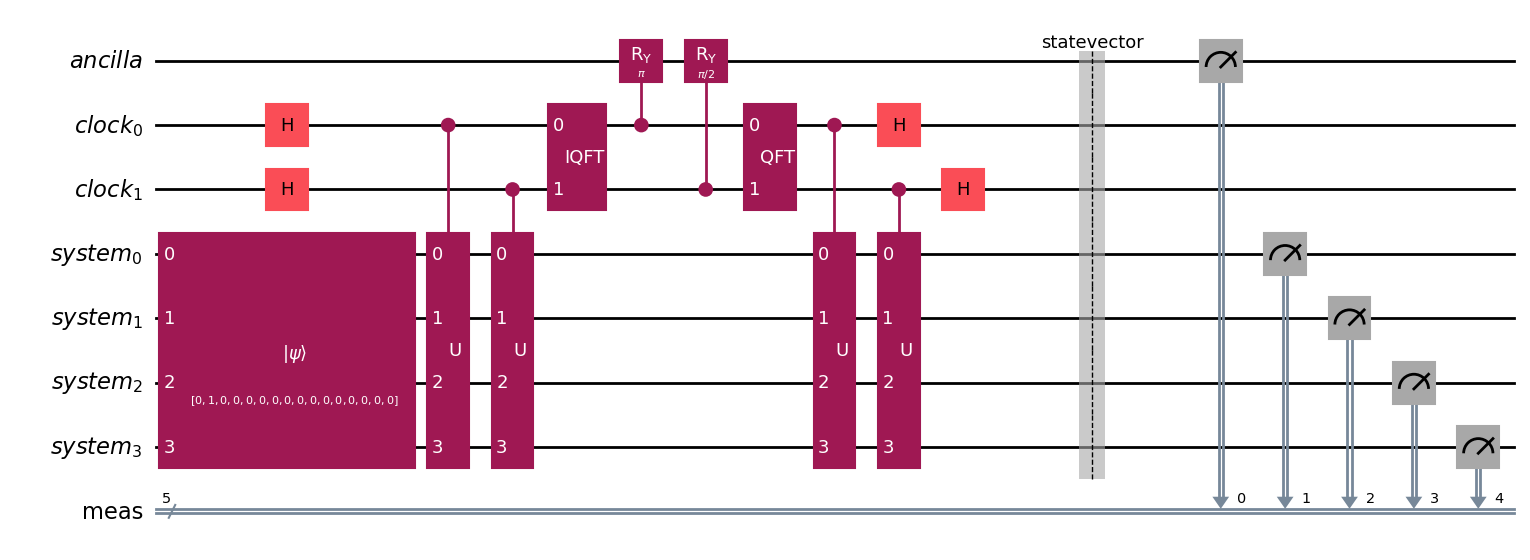

In [17]:
n_system = 4      # 2^4 = 16
n_clock = 2
num_phase_qubits = 2

qc = build_hhl_circuit(U, b, num_phase_qubits, n_system, n_clock)

qc.draw("mpl")

In [18]:
from qiskit_aer import AerSimulator
from qiskit import transpile

sim = AerSimulator(method="statevector")

qc_compiled = transpile(qc, sim)
result = sim.run(qc_compiled).result()

state = result.get_statevector()
print(state)

Statevector([ 1.65810776e-14-2.55838227e-14j,
              5.24555037e-14-2.28616269e-15j,
             -4.48276619e-14-1.15176737e-14j,
             -9.20753886e-14+2.88161345e-14j,
             -1.31955658e-14-9.83553508e-14j,
              3.13129937e-14+3.43553012e-14j,
              2.12517423e-14+5.07160132e-14j,
              1.76742437e-14-2.61641502e-14j,
              3.01776695e-01+2.01013167e-14j,
              4.78553391e-01+4.75089738e-15j,
             -3.55619043e-15-1.25000000e-01j,
             -2.87694386e-15-5.17766953e-02j,
              1.70296370e-14-1.25000000e-01j,
             -1.60652857e-16-5.17766953e-02j,
             -5.17766953e-02+1.82995460e-14j,
              1.25000000e-01-3.59229991e-15j,
             -2.58038163e-14+9.58374448e-15j,
             -4.11703482e-14+8.86633036e-15j,
              1.91239535e-14+1.23695697e-14j,
              6.85539801e-14+5.93811801e-15j,
              8.60473072e-16+1.40457191e-14j,
             -1.35912454e-14-2.642

In [19]:
import numpy as np

state = np.array(state)
total_qubits = 1 + n_clock + n_system
solution = []

for i in range(len(state)):
    if (i >> (total_qubits - 1)) & 1:   # check ancilla bit
        solution.append(state[i])

solution = np.array(solution)
solution = solution / np.linalg.norm(solution)

print("Solution |x> =")
print(solution)

Solution |x> =
[-1.64141449e-01-9.90329614e-02j  3.62233273e-01-2.96590828e-01j
  3.47578566e-02-1.00516496e-01j -1.00354225e-01-1.53103307e-02j
  1.63863099e-01+3.59706751e-01j -3.69840893e-01+9.85432750e-02j
 -1.81626942e-02-9.56993346e-02j  1.04245528e-01+2.89878254e-02j
 -2.72744256e-02-3.92640811e-03j -2.69656310e-03-1.93528365e-01j
 -3.84119720e-02+2.17116724e-02j -3.95695460e-02+9.74809782e-02j
 -1.75578921e-03+9.26549860e-02j  3.26787529e-02+2.16494160e-02j
  2.29122961e-03-1.03306619e-01j -6.29966811e-03-2.66763828e-02j
 -2.11502087e-02+1.76521116e-02j  2.02534252e-03+1.92129391e-03j
  1.34616700e-03+1.67322571e-03j  2.66849706e-04+6.32219344e-05j
  1.31275611e-02-1.15765529e-02j -1.50118797e-03-8.00101921e-03j
 -4.85252485e-04-6.23525632e-04j  1.15955426e-03+2.97257573e-03j
  3.18877552e-02-1.97429636e-02j  3.49172226e-02-2.66886230e-02j
 -2.83062624e-03-8.92645889e-03j -5.01816102e-02+1.13736564e-02j
  1.32361497e-02+3.48072985e-02j -3.35822920e-02-2.81231376e-02j
 -4.959579